<a href="https://colab.research.google.com/github/Devil-Gaming-Studios/AlgoNinjas_ClaudeSolvathon/blob/main/logestic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
y = np.array([1,1,1,0,0])
x = np.array([[1,0,0],[0,0,1],[0,1,0],[1,1,0],[1,0,1]])

In [ ]:

# Features (X)
x = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [5, 6],
    [6, 7],
    [7, 8],
    [1, 0],
    [2, 1],
    [6, 5],
    [7, 6]
])

# Labels (y)
y = np.array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1])

In [ ]:
train_data = [
    # 🔴 Spam (1)
    ("Congratulations! You've won a $1000 gift card. Click here to claim.", 1),
    ("URGENT: Your account has been compromised. Reset your password now!", 1),
    ("Win cash prizes now!!! Limited time offer, hurry up!", 1),
    ("Get cheap loans instantly with zero paperwork", 1),
    ("Exclusive deal just for you. Buy now and save big", 1),
    ("You have been selected for a free vacation. Call now!", 1),
    ("Earn money from home without any investment", 1),
    ("This is not a scam! Claim your reward today", 1),
    ("Act now! Lowest prices guaranteed for today only", 1),
    ("Click this link to verify your bank details immediately", 1),
    ("Hot singles in your area waiting for you", 1),
    ("You won a lottery! Send your details to receive funds", 1),

    # 🟢 Not Spam (0)
    ("Hey, are we still meeting tomorrow?", 0),
    ("Please send me the notes from today's lecture", 0),
    ("Let's have lunch together at 2 PM", 0),
    ("Can you call me when you're free?", 0),
    ("Reminder: your class starts at 10 AM", 0),
    ("Don't forget to submit your assignment", 0),
    ("Are you coming to the party tonight?", 0),
    ("I'll reach the station by 6 PM", 0),
    ("Can we reschedule our meeting?", 0),
    ("Thanks for your help yesterday!", 0),
    ("Meeting agenda has been shared on email", 0),
    ("Please review the document and give feedback", 0),
]

In [ ]:
X_train = [text for text, label in train_data]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X_train)

In [ ]:

def data_set_creator(train_data,vectorizer):
  X_train = [text for text, label in train_data]
  y = [label for text, label in train_data]
  X = vectorizer.transform(X_train)

  m,n = X.shape[0], X.shape[1]

  x = X.toarray()
  return x,y

In [ ]:
x, y = data_set_creator(train_data,vectorizer)

In [ ]:
x.shape

(24, 128)

In [ ]:
def fixer(x):
  return np.hstack((x, np.ones(x.shape[0])[:, np.newaxis]))
x = fixer(x)

In [ ]:
x

array([[0., 1., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 2., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

def data_set_vectorizer(raw_data, fitted_vectorizer):
  X_raw = [text for text, label in raw_data]
  y = [label for text, label in raw_data]
  X_transformed = fitted_vectorizer.transform(X_raw)
  x_array = X_transformed.toarray()
  return x_array, y

In [ ]:
w = np.zeros(x.shape[1])
alpha = 0.01

In [ ]:
w.shape

(129,)

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [ ]:
for i in range(10000):
  z = x@w
  y_hat = sigmoid(z)
  dw = (y_hat - y)@x
  w -= alpha*dw

In [ ]:
w

array([-0.92504039,  0.59274411,  0.69030838,  0.64607179, -0.9940463 ,
       -0.92504039, -0.01583638,  1.25731753, -1.42960991,  1.10177937,
       -1.48173183, -1.82091918,  0.77291786,  0.75261212,  0.5656645 ,
        0.5656645 , -0.56691689, -0.25344607, -1.91137924,  0.59274411,
        0.65223792,  1.16274008,  1.52098423, -0.92504039,  1.36566197,
       -0.86261928,  0.69030838,  0.59274411,  0.5656645 ,  1.79277098,
       -0.58150088, -1.48173183,  1.25731753, -0.9940463 ,  0.5656645 ,
       -0.58150088,  1.16825045, -1.48173183, -0.25344607,  0.50978648,
        1.01985313,  1.16274008,  0.59274411, -0.58150088,  0.64607179,
       -0.30373792,  0.16047125, -2.20161524,  0.59274411, -0.56699063,
        1.25731753,  1.10177937,  0.65223792,  0.77291786,  1.10177937,
        1.16274008,  1.25731753,  0.92824011,  0.5656645 , -0.74753105,
       -0.89587879,  0.65223792,  0.77291786, -0.56691689,  1.16274008,
        1.01985313,  0.64607179, -0.89587879, -2.05732716, -2.16

In [ ]:
len(w)

129

In [ ]:
def tester(x,y,w):
  x = np.hstack((x, np.ones([w.shape[0]-1 - x.shape[1],x.shape[0]]).T))
  x = fixer(x)
  pred = sigmoid(x@w)
  corrects = 0.0
  total = len(y)
  print(len(y))
  print(pred)

  for i in range(total):
    if (pred[i]> 0.5 and y[i] == 1) or (pred[i]<0.5 and y[i] == 0):
      corrects += 1
  print(corrects)
  return (corrects/total)*100.0

In [ ]:
test_data = [
    # 🔴 Spam (1)
    ("You have been chosen to receive a cash reward. Act fast!", 1),
    ("Limited offer! Grab your discount before it expires tonight", 1),
    ("Your bank account needs verification. Click the link below", 1),
    ("Make thousands working from your home easily", 1),
    ("Free entry into our prize draw. Don’t miss out!", 1),
    ("Lowest interest loans available instantly, apply now", 1),
    ("Congratulations, you are our lucky winner today!", 1),
    ("Immediate action required: update your payment details", 1),
    ("Earn extra income with no prior experience needed", 1),
    ("Special promotion just for selected users. Shop now", 1),

    # 🟢 Not Spam (0)
    ("Let’s catch up sometime this week", 0),
    ("I have sent you the files, please check", 0),
    ("Are you coming to class today?", 0),
    ("Don’t forget to submit your assignment", 0),
    ("Can you call me when you’re free?", 0),
    ("Lunch at 2 pm sounds good?", 0),
    ("Please find the attached report", 0),
    ("I’ll be late to the meeting", 0),
    ("Did you complete the project work?", 0),
    ("Let me know your availability for tomorrow", 0)
]
X_test, y_test = data_set_creator(test_data, vectorizer)
X_test.shape

tester(X_test,y_test,w)

20
[0.97737476 0.43729454 0.53723892 0.74518564 0.02593747 0.99499927
 0.25989504 0.75002864 0.75602928 0.99401129 0.54202348 0.01259258
 0.05818557 0.00138625 0.0012594  0.00419934 0.00460212 0.00118602
 0.03941431 0.04539256]
16.0


80.0

ValueError: x and y must have same first dimension, but have shapes (128,) and (20,)

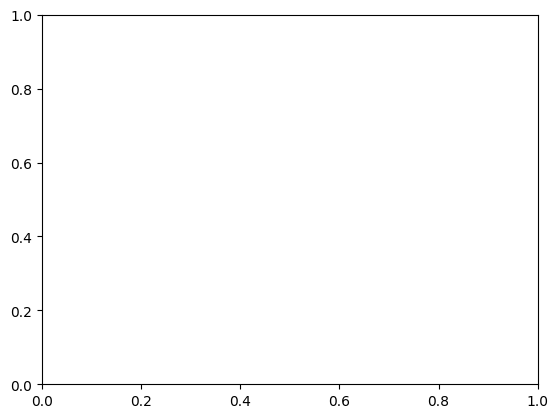

In [ ]:
plt.plot(X_test[0],y_test)
plt.show()